In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.signal as sig

In [9]:
df = pd.read_csv('data/PK Test 3_0_cal_data.csv')
print(df.head())

t = df['t'].tolist()
fork_x = df['a0'].tolist()
shock_x = df['b0'].tolist()
sWheelr = df['sWheelr'].tolist() # 'motion ratio + shock distance
gx = df['gx'].values
gy = df['gy'].values
gz = df['gz'].values

   tmicros      t        a0        b0  c0  d0        gx        gy         gz  \
0        0  0.000  0.003204  0.000377   0   0 -0.389914 -0.076641  10.019907   
1     2000  0.002  0.003204  0.000377   0   0 -0.706835  0.052690  10.299315   
2     4000  0.004  0.003253  0.000402   0   0 -0.385323 -0.565225  10.088837   
3     6000  0.006  0.003253  0.000377   0   0 -0.141152 -0.009580  10.076571   
4     8000  0.008  0.003302  0.000402   0   0 -0.522563 -0.383203  10.067353   

         wx        wy        wz        Tx        Ty        Tz   sWheelr  \
0 -0.002132  0.000000  0.024515  0.000007 -0.000006 -0.000017  0.001247   
1 -0.177730  0.009060 -0.085268  0.000007 -0.000006 -0.000017  0.001247   
2  0.035706  0.034374 -0.092462  0.000007 -0.000006 -0.000017  0.001328   
3 -0.026113  0.004263  0.003997  0.000007 -0.000007 -0.000017  0.001247   
4 -0.042634 -0.004796 -0.078873  0.000007 -0.000007 -0.000017  0.001328   

   wWheelr  vBike   unix_time  
0      0.0    0.0  1684852364  
1   

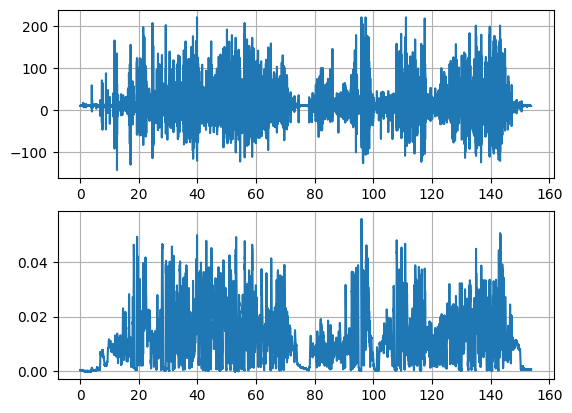

In [31]:
plt.subplot(2,1,1)
plt.plot(t, gz)
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t, shock_x)
plt.grid(True)

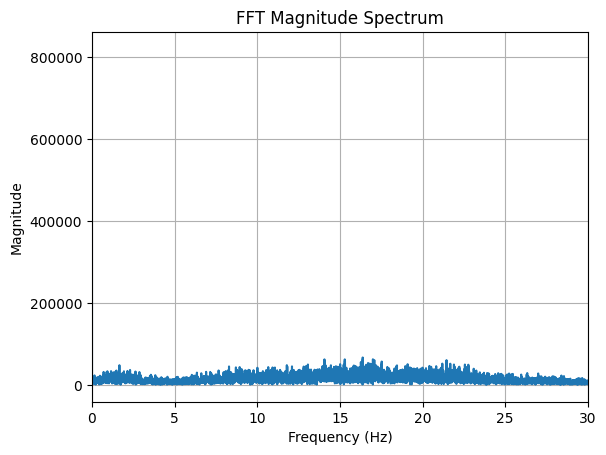

In [20]:
fft_result = np.fft.fft(gz)
freqs = np.fft.fftfreq(len(t), d=0.002)

positive_freqs = freqs[:len(freqs)//2]
fft_magnitude = np.abs(fft_result[:len(fft_result)//2])

plt.plot(positive_freqs, fft_magnitude)
plt.title("FFT Magnitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim([0, 30])
plt.grid(True)
plt.show()

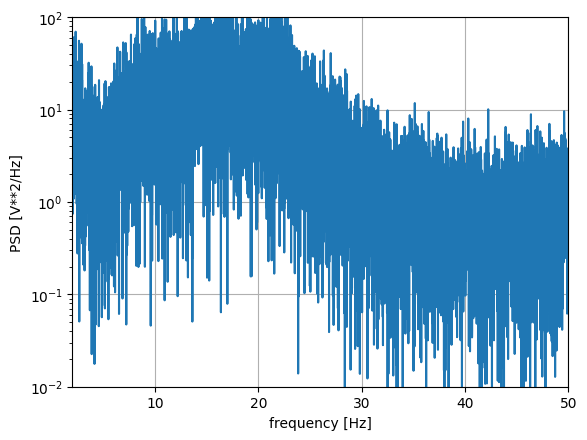

In [30]:
f, pxx = sig.periodogram(gz, 1/0.002)

plt.semilogy(f, pxx)
plt.ylim([1e-2, 1e2])
plt.xlim([2, 50])
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.grid(True)
plt.show()

## Next Idea
Use the sum of the forces and the moments to find the characteristics of the suspension
      ^
 __|  |y
0  0  ->x
^  ^

$$
\sum F_x = m a_x\\
\sum F_y = F_{fw} + F_{rw} -mg = m a_y\\

\sum M_z = M_{fw} - M_{rw}\\
$$

assumptions: 
- there are no forces in the x because all forces hit directly under the axle in the positive vertical direction

$$
F_{rw} = kx + bv
$$
where x and v are wheel displacement and velocities which is also shock displacement and velocities

$$
F_{fw} = kx + bv
$$
same for the front fork

## Examine the Moments

$$
M_{fw} = r * F_{fw}
$$

where r is the leverarm from the fork to the center of mass of the rider and bike geometry. Could be found from bike geo.

$$
M_{rw} = r * F_{rw}
$$

same for the rear

$$
M = I * \ddot \theta
$$

The resulting angular acceleration, can be measured by the onboard IMU